# Feature Importance and Model Interpretability

After evaluating the performance of regression models, it is important to understand how individual features contribute to predictions.

Model performance metrics such as RMSE and R-squared indicate how well the model fits the data, but they do not explain the influence of each variable.

Feature importance analysis helps to:

- Identify the most influential predictors
- Understand the direction of relationships
- Provide insights for decision-making
- Improve model transparency

In linear regression, feature importance is derived from model coefficients.

## Import Required Libraries

We use:

- `dplyr`: data manipulation  
- `ggplot2`: visualization  
- `broom`: tidy model outputs  

In [1]:
# Load required libraries

# dplyr for data manipulation
library(dplyr)

# ggplot2 for visualization
library(ggplot2)

# broom to convert model output into tidy format
library(broom)


Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Load Cleaned Dataset

We reload the wrangled dataset produced by notebook 02 (`clean_bike_data.csv`) so this notebook runs independently from a fresh kernel.

In [ ]:
# ── Load Cleaned Dataset ──────────────────────────────────────
library(readr)                                  # fast CSV reader from tidyverse
bike_data <- read_csv("clean_bike_data.csv")    # load wrangled dataset produced by notebook 02
cat("Rows:", nrow(bike_data), "\n")             # log row count to confirm successful load


## Chronological Train/Test Split and Full Model

We mirror the chronological 80/20 split used in earlier notebooks, drop the redundant `date` and constant `functioning_day` columns, then fit a full linear model (`rented_bike_count ~ .`). Coefficients from this fit drive the feature-importance analysis below.

In [ ]:
# ── Chronological 80/20 Split ─────────────────────────────────
bike_data <- bike_data %>% arrange(date)                        # sort rows by date for time-aware split
bike_data <- bike_data %>% select(-date, -functioning_day)      # drop date (already encoded) and constant functioning_day
split_idx  <- floor(nrow(bike_data) * 0.8)                      # index of last training row (first 80%)
train_data <- bike_data[1:split_idx, ]                          # earliest 80% becomes training set
test_data  <- bike_data[(split_idx + 1):nrow(bike_data), ]      # latest 20% becomes held-out test set


In [ ]:
# ── Train Full Linear Model ───────────────────────────────────
model <- lm(rented_bike_count ~ ., data = train_data)    # fit OLS using every remaining predictor
cat("Model trained\n")                                   # confirm fit completed


## Extract Model Coefficients

We extract coefficients from the model to analyze feature importance.

In [5]:
# Convert model output into tidy format

model_summary <- tidy(model)

# Display coefficients
model_summary

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.019514e+06,2.072310e+05,9.745234,2.710506e-22
hour,2.640006e+01,8.422010e-01,31.346510,1.720369e-201
temperature,2.466175e+01,3.933082e+00,6.270337,3.825085e-10
humidity,-9.231243e+00,1.092286e+00,-8.451303,3.493419e-17
wind_speed,2.627543e+01,5.665071e+00,4.638147,3.581710e-06
visibility,4.387308e-02,1.297462e-02,3.381455,7.251252e-04
dew_point_temperature,7.913208e+00,4.113000e+00,1.923950,5.440281e-02
solar_radiation,-8.798686e+01,8.367718e+00,-10.515036,1.162028e-25
rainfall,-5.502608e+01,4.611135e+00,-11.933304,1.681855e-32


## Feature Importance Based on Magnitude

The absolute value of coefficients indicates the strength of influence.

Higher magnitude Ã¢â€ â€™ stronger impact on predictions.

In [6]:
# Calculate absolute coefficient values

feature_importance <- model_summary %>%
  filter(term != "(Intercept)") %>%
  mutate(abs_coef = abs(estimate)) %>%
  arrange(desc(abs_coef))

# Display ranked features
feature_importance

term,estimate,std.error,statistic,p.value,abs_coef
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
year,-1.000055e+03,102.66070531,-9.741364,2.814291e-22,1.000055e+03
seasonsWinter,-8.839506e+02,64.99858362,-13.599536,1.417381e-41,8.839506e+02
seasonsSpring,-4.900131e+02,49.30900674,-9.937598,4.114388e-23,4.900131e+02
seasonsSummer,-3.270111e+02,35.93258160,-9.100685,1.161917e-19,3.270111e+02
day_of_weekSunday,-1.614814e+02,19.49576843,-8.282894,1.436643e-16,1.614814e+02
holidayNo Holiday,1.164042e+02,25.46684915,4.570811,4.944915e-06,1.164042e+02
day_of_weekMonday,-1.061220e+02,19.56493264,-5.424093,6.027066e-08,1.061220e+02
day_of_weekSaturday,-1.029119e+02,19.49356507,-5.279277,1.337408e-07,1.029119e+02
solar_radiation,-8.798686e+01,8.36771797,-10.515036,1.162028e-25,8.798686e+01


## Visualize Feature Importance (Magnitude)

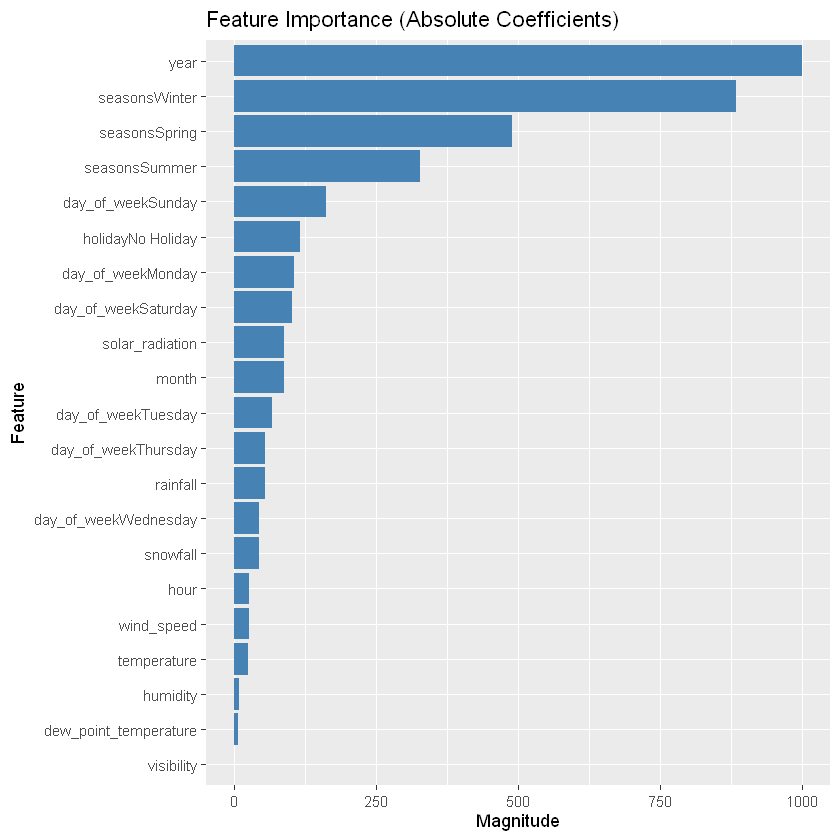

In [7]:
# Plot feature importance based on magnitude

ggplot(feature_importance, aes(x = reorder(term, abs_coef), y = abs_coef)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Feature Importance (Absolute Coefficients)",
    x = "Feature",
    y = "Magnitude"
  )

## Feature Influence Direction

The sign of the coefficient indicates:

- Positive Ã¢â€ â€™ increases bike demand
- Negative Ã¢â€ â€™ decreases bike demand

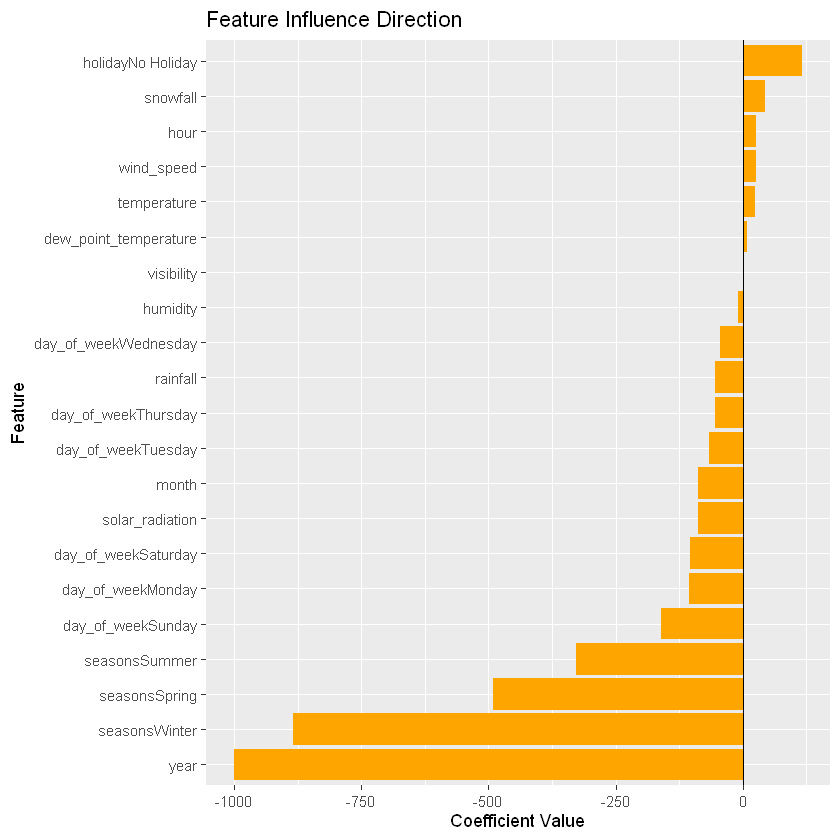

In [8]:
# Plot coefficients with direction

ggplot(feature_importance, aes(x = reorder(term, estimate), y = estimate)) +
  geom_bar(stat = "identity", fill = "orange") +
  coord_flip() +
  geom_hline(yintercept = 0, color = "black") +
  labs(
    title = "Feature Influence Direction",
    x = "Feature",
    y = "Coefficient Value"
  )

## Interpretation of Results

From the feature importance analysis:

- Features with large positive coefficients strongly increase bike demand
- Features with large negative coefficients reduce demand
- Polynomial terms capture non-linear effects
- Interaction terms reveal combined influence of variables

Weather-related features such as temperature typically have strong influence, while humidity may negatively affect demand.

Understanding these relationships helps improve model design and supports business decision-making.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on interpreting regression models by analyzing feature importance using model coefficients and visualization techniques.

The workflow follows <span style="color:blue">IBM Skills Network </span> instructional labs on model interpretation and feature importance analysis.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo </span>  
- <span style="color:blue">Jeff Grossman</span>  
- <span style="color:blue">Rav Ahuja et al. at the IBM Skills Network</span>  

---

## Project Context

This notebook represents the model interpretability stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- Baseline Model Development  
- Model Refinement  
- Model Evaluation & Diagnostics  
- **Feature Importance Analysis**  
- Deployment (R Shiny Dashboard)

---

## Notes

Feature importance analysis enhances transparency by explaining how individual variables influence model predictions.

---